In [2]:
import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np
import os 
from pathlib import Path
import torch 

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

In [2]:
# data loading 
PATH_DATA = Path('data')
PATH_sim_data = PATH_DATA / 'simulation_data' / 'test_4_final.imzML'
print(PATH_sim_data.exists())
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
reader_real = m2.ImzMLReader(str(PATH_real_data))


True
True
!Tue Apr 21 18:49:17 2026 
2.378! WARNING: No pixel size found, set x and y spacing to 50 microns!
!5.417! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[6.293] [imzML]: data/bladder_data/mouse_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements


In [25]:
# --- CONFIGURATION ---
PIXEL_IDX = 15000 
TARGET_MZ = 798.5 
TOLERANCE = 50     # ppm
WIDE_WINDOW = 5    # m/z for overview
ZOOM_WINDOW = 0.5  # m/z for detailed peak analysis

def reset_reader(reader):
    """Resets all signal processing steps in M2aia reader."""
    reader.SetNormalization("None")
    reader.SetSmoothing("None", 0)
    reader.SetBaselineCorrection("None", 0)

def plot_comparison(results, title_prefix):
    """
    Enhanced plotting function with 3 rows: Overview, Zoomed Peak, and Ion Image.
    Includes a semi-transparent vertical line at the target m/z.
    """
    n = len(results)
    # 3 Rows: Wide Spectrum, Zoomed Spectrum, Ion Image
    fig, axes = plt.subplots(3, n, figsize=(5 * n, 12), squeeze=False)
    fig.suptitle(title_prefix, fontsize=18, fontweight='bold', y=0.98)

    for i, res in enumerate(results):
        # ROW 0: Overview Spectrum
        ax_wide = axes[0, i]
        ax_wide.plot(res['mzs'], res['ints'], color='tab:blue', linewidth=1)
        ax_wide.axvline(x=TARGET_MZ, color='black', linestyle='--', alpha=0.3)
        ax_wide.set_xlim(TARGET_MZ - WIDE_WINDOW, TARGET_MZ + WIDE_WINDOW)
        ax_wide.set_title(f"Overview: {res['name']}")
        ax_wide.grid(True, alpha=0.2)

        # ROW 1: Zoomed Spectrum (The "Microscope")
        ax_zoom = axes[1, i]
        ax_zoom.plot(res['mzs'], res['ints'], color='tab:red', linewidth=1.5)
        ax_zoom.axvline(x=TARGET_MZ, color='black', linestyle='--', alpha=0.3)
        ax_zoom.set_xlim(TARGET_MZ - ZOOM_WINDOW, TARGET_MZ + ZOOM_WINDOW)
        ax_zoom.set_title(f"Zoomed Peak: {res['name']}")
        ax_zoom.set_xlabel("m/z")
        ax_zoom.grid(True, alpha=0.2)

        # ROW 2: Ion Image
        ax_img = axes[2, i]
        im = ax_img.imshow(res['img'], cmap='viridis')
        ax_img.set_title(f"Spatial: {res['name']}")
        ax_img.axis('off')
        plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- COMPARISON FUNCTIONS ---

def compare_normalization(reader, norm_types=["TIC", "RMS", "None"]):
    """Compares normalization methods (No smoothing/baseline)."""
    results = []
    for nt in norm_types:
        reset_reader(reader)
        reader.SetNormalization(nt)
        
        mzs, ints = reader.GetSpectrum(PIXEL_IDX)
        img = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, True)
        results.append({'name': f"Norm: {nt}", 'mzs': mzs, 'ints': ints, 'img': img})
    
    plot_comparison(results, "Normalization Impact")

def compare_smoothing(reader, normalization="TIC", methods_config=None):
    """
    Compares Gaussian/SG. 
    Default: Gaussian with half-window sizes [2, 10, 50].
    Note: 'p' is the number of neighbor points (int).
    """
    if methods_config is None:
        methods_config = {'Gaussian': [2, 10, 50]}

    results = []
    for method, params in methods_config.items():
        for p in params:
            p_int = int(p) # M2aia requires int for discrete window indexing
            reset_reader(reader)
            reader.SetNormalization(normalization)
            reader.SetSmoothing(method, p_int)
            
            mzs, ints = reader.GetSpectrum(PIXEL_IDX)
            img = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, True)
            results.append({'name': f"{method}({p_int})", 'mzs': mzs, 'ints': ints, 'img': img})
            
    plot_comparison(results, f"Smoothing Comparison (Base: {normalization})")

def compare_baseline(reader, normalization="TIC", methods_config=None):
    """
    Compares Baseline methods. 
    TopHat p=50 means the structuring element spans 101 points.
    """
    if methods_config is None:
        methods_config = {'TopHat': [50, 150]}

    results = []
    for method, params in methods_config.items():
        for p in params:
            p_int = int(p)
            reset_reader(reader)
            reader.SetNormalization(normalization)
            reader.SetBaselineCorrection(method, p_int)
            
            mzs, ints = reader.GetSpectrum(PIXEL_IDX)
            img = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, True)
            results.append({'name': f"{method}({p_int})", 'mzs': mzs, 'ints': ints, 'img': img})
            
    plot_comparison(results, "Baseline Correction Comparison")

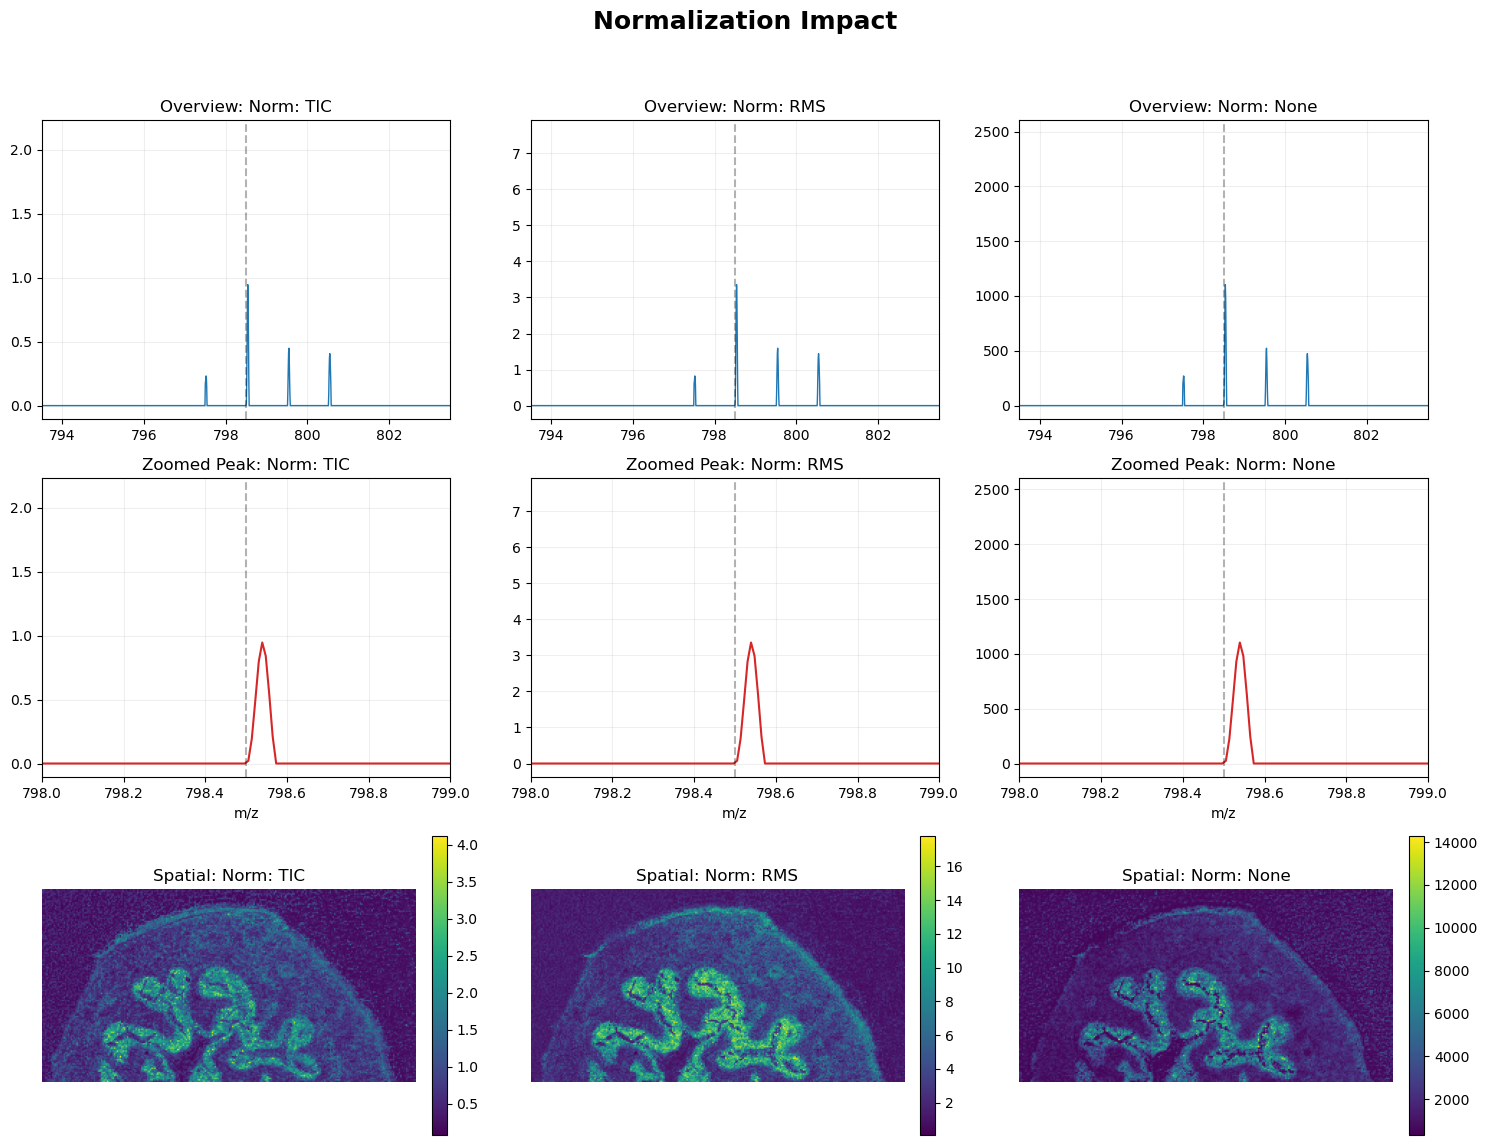

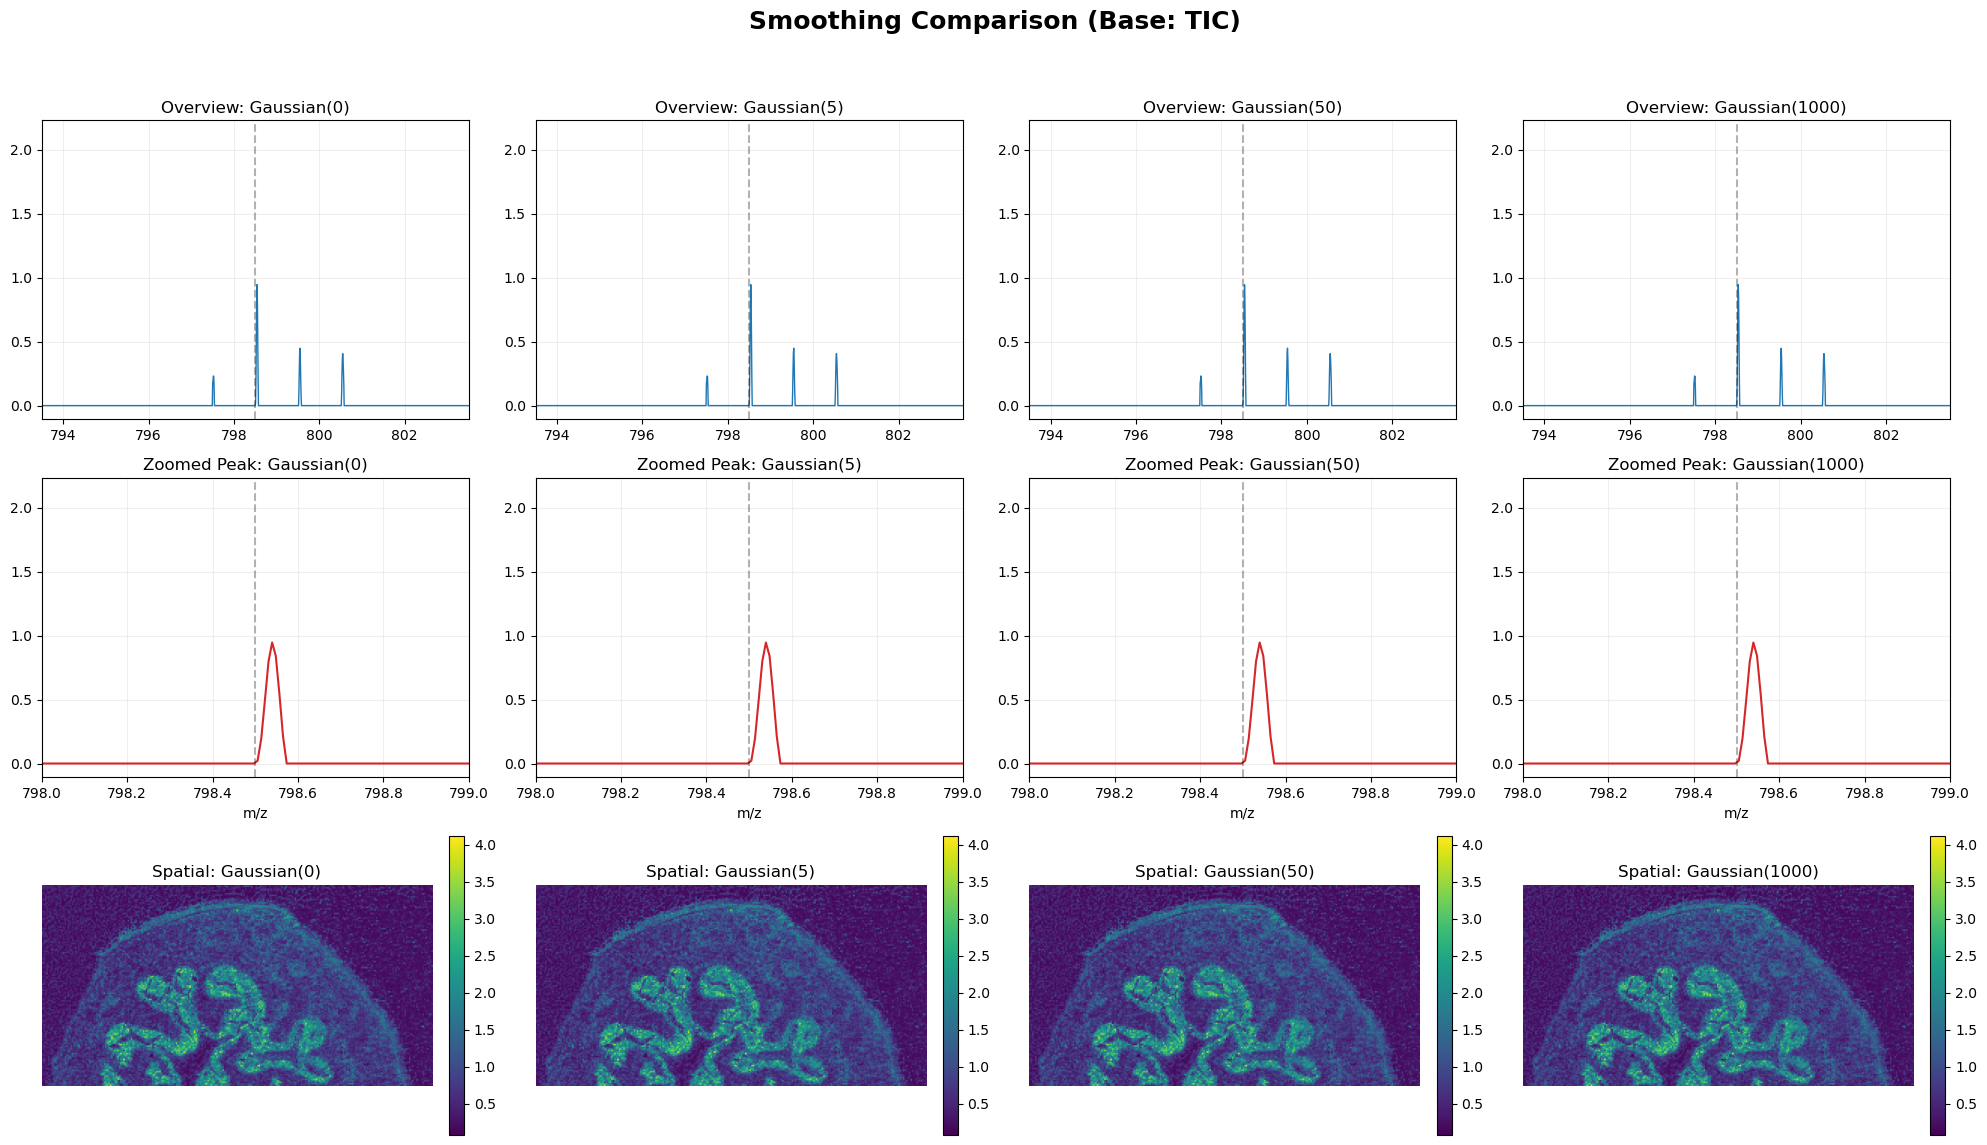

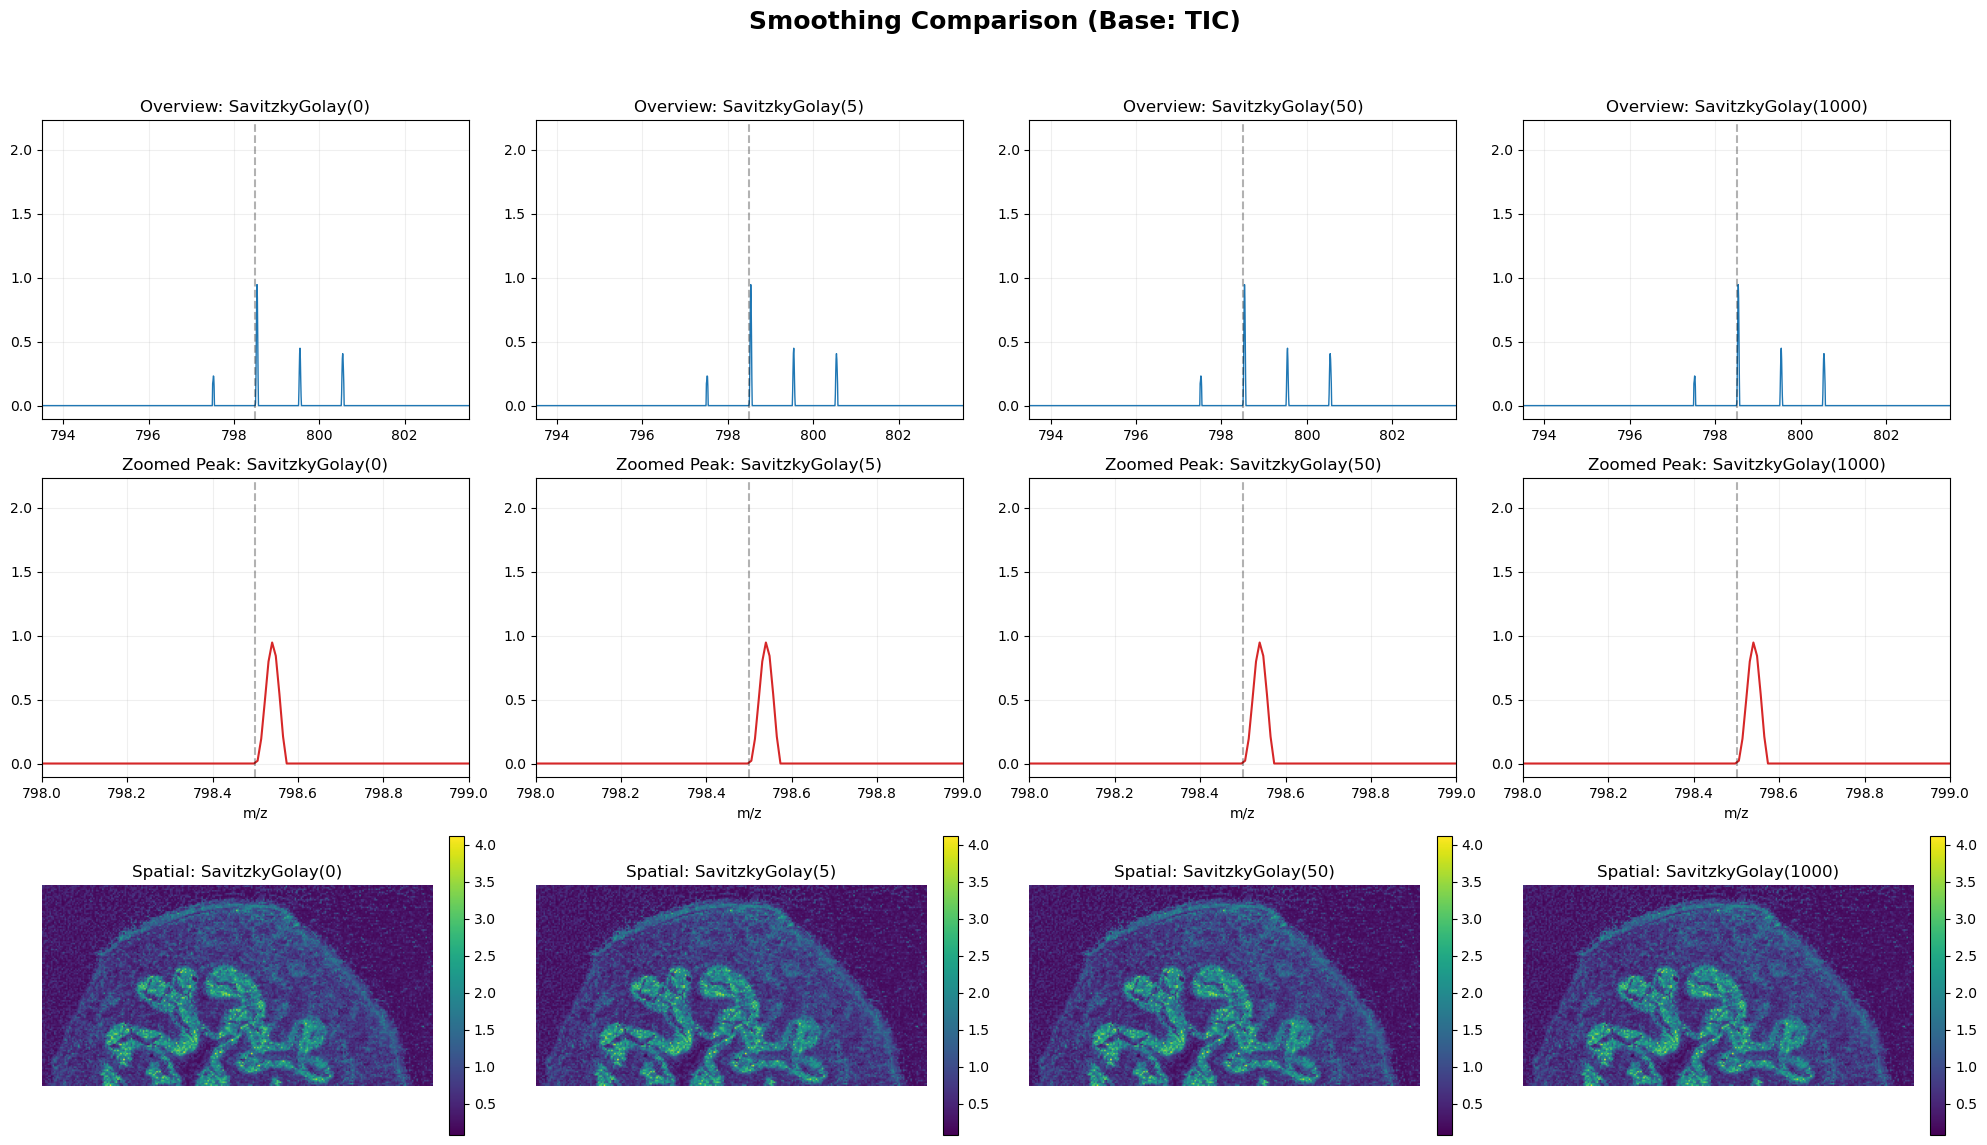

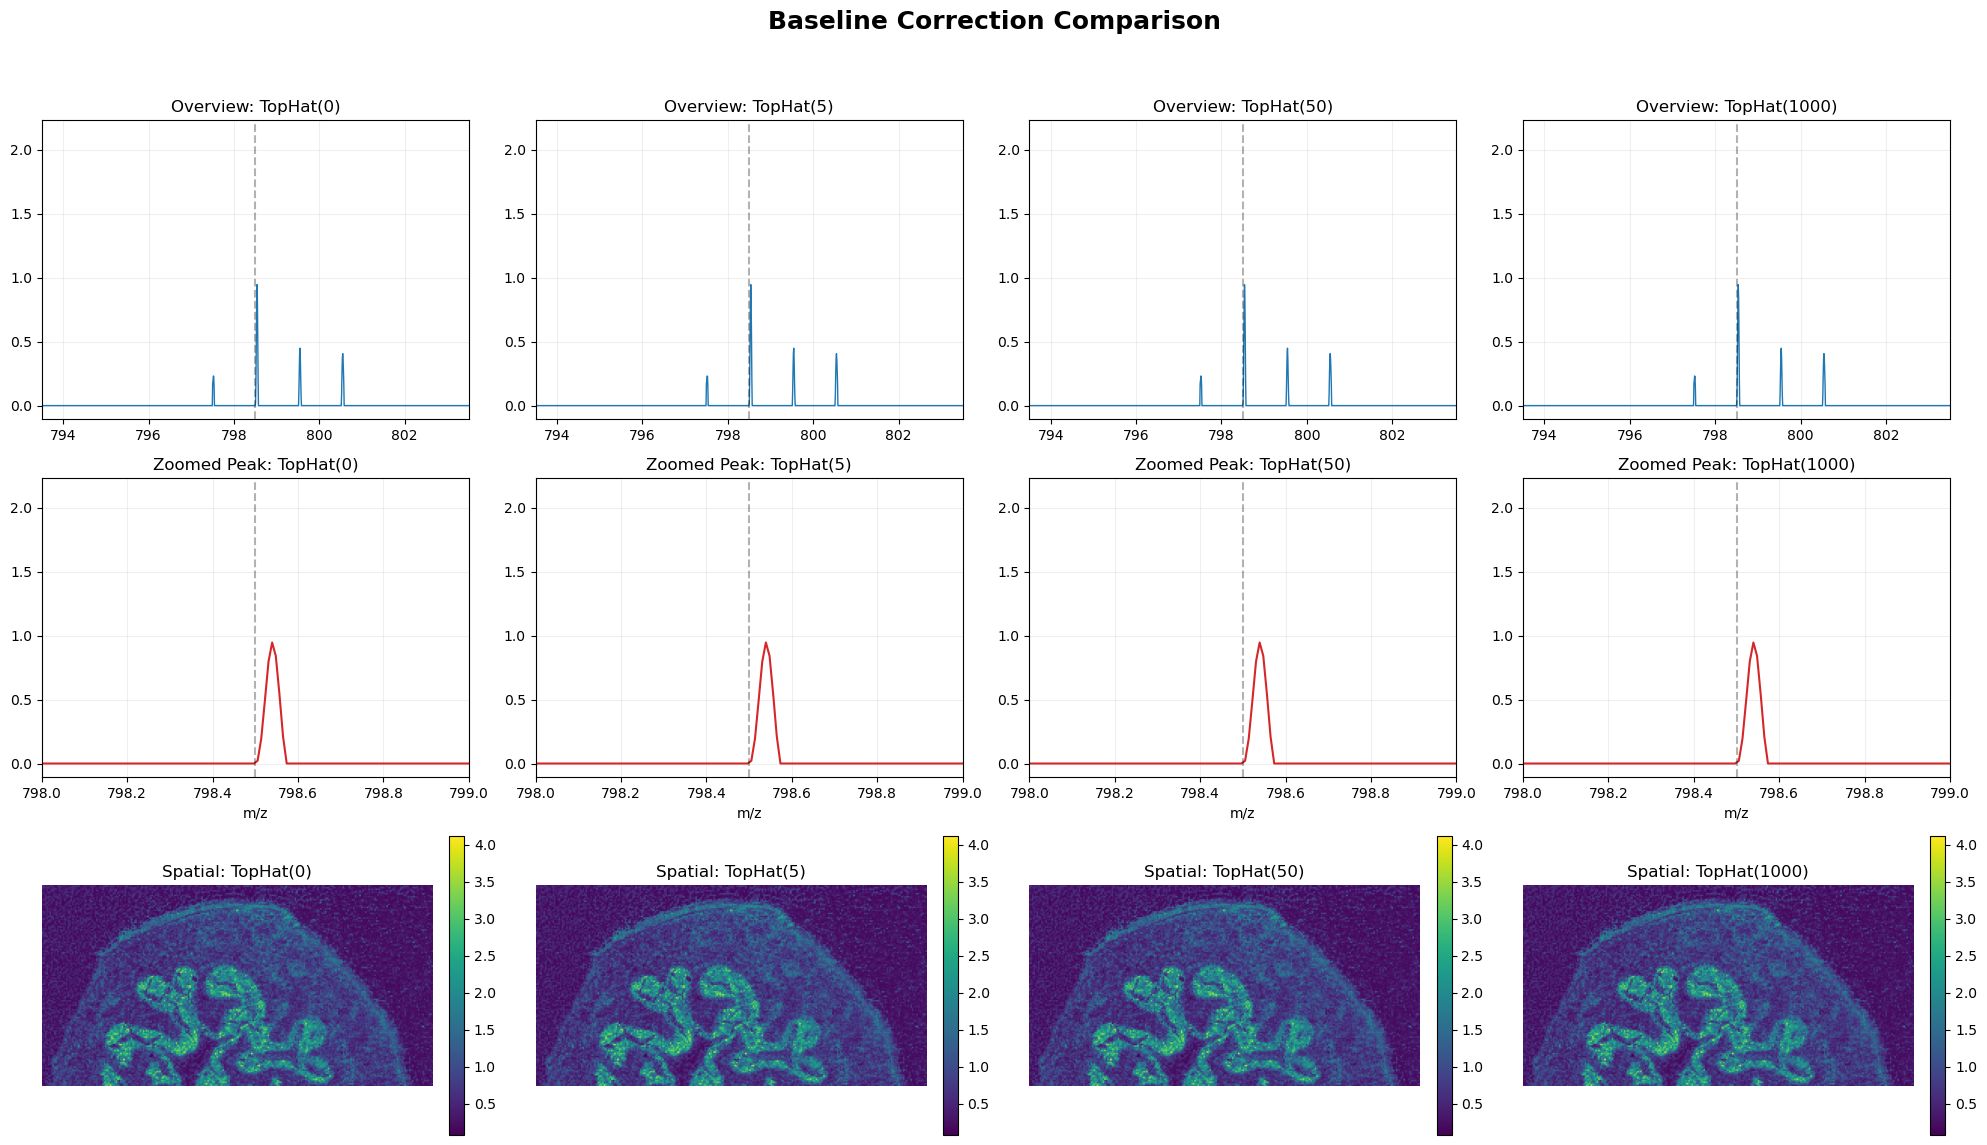

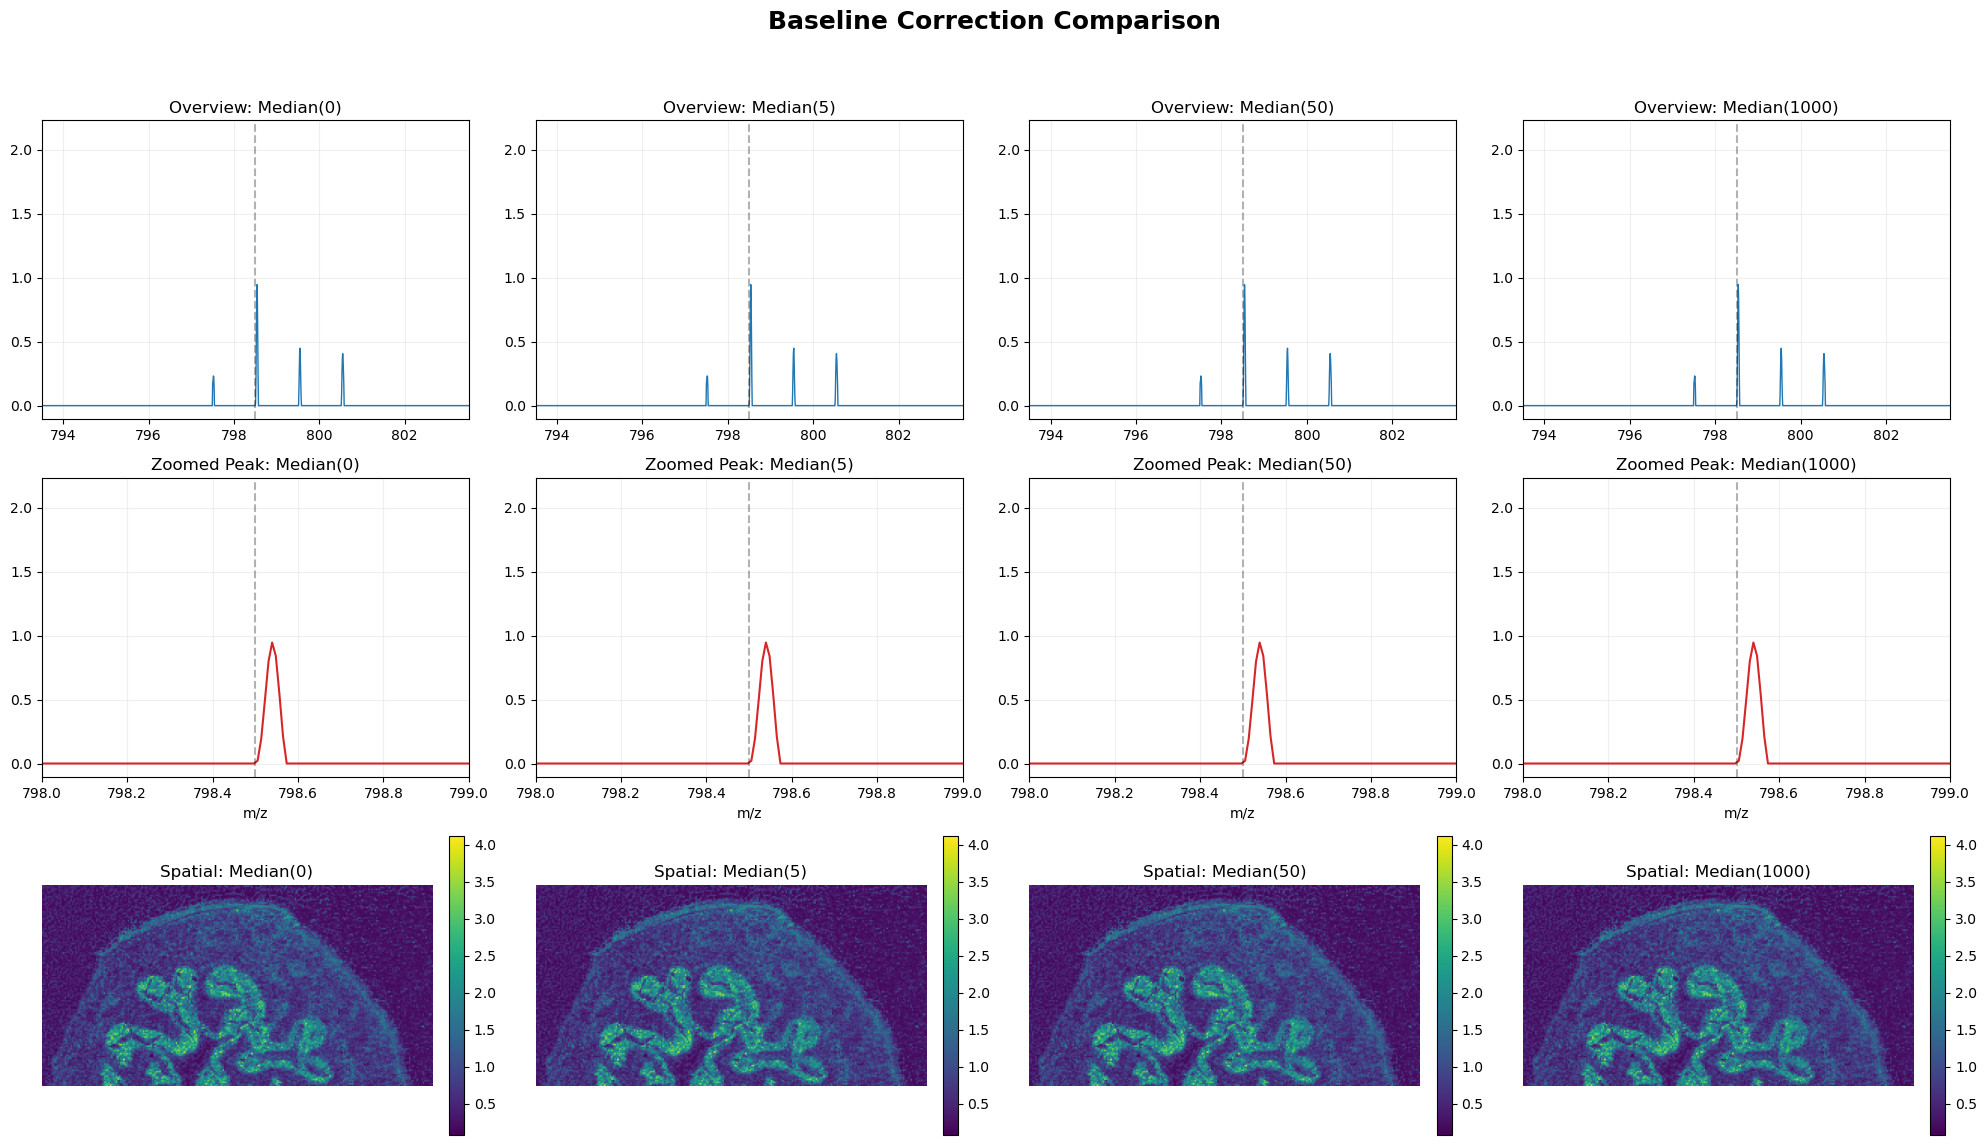

In [ ]:
# --- EXECUTION ---

# 1. Compare Normalization (TIC vs RMS vs None)
compare_normalization(reader_real)

# 2. Compare Smoothing 
# Gaussian sigmas: 0.5 (low), 10 (medium), 60 (high/over-smoothed)
# Savitzky-Golay: window sizes (must be odd)
smoothing_tests_gaussian = {
    'Gaussian': [0, 5, 50, 1000],      # Zmienione z 0.5 na 1
}
smoothing_tests_Savitsky = {
    'SavitzkyGolay': [0, 5, 50, 1000]      # Odpowiada oknom o rozmiarze 7 i 15 punktów
}


compare_smoothing(reader_real, normalization="TIC", methods_config=smoothing_tests_gaussian)
compare_smoothing(reader_real, normalization="TIC", methods_config=smoothing_tests_Savitsky)
# 3. Compare Baseline Correction
# Using TopHat and Median filters with different window sizes
baseline_tests_top_hat = {
    'TopHat': [0, 5, 50, 1000]
}
baseline_tests_median = {
    'Median': [0, 5, 50, 1000],
}

compare_baseline(reader_real, normalization="TIC", methods_config=baseline_tests_top_hat)
compare_baseline(reader_real, normalization="TIC", methods_config=baseline_tests_median)

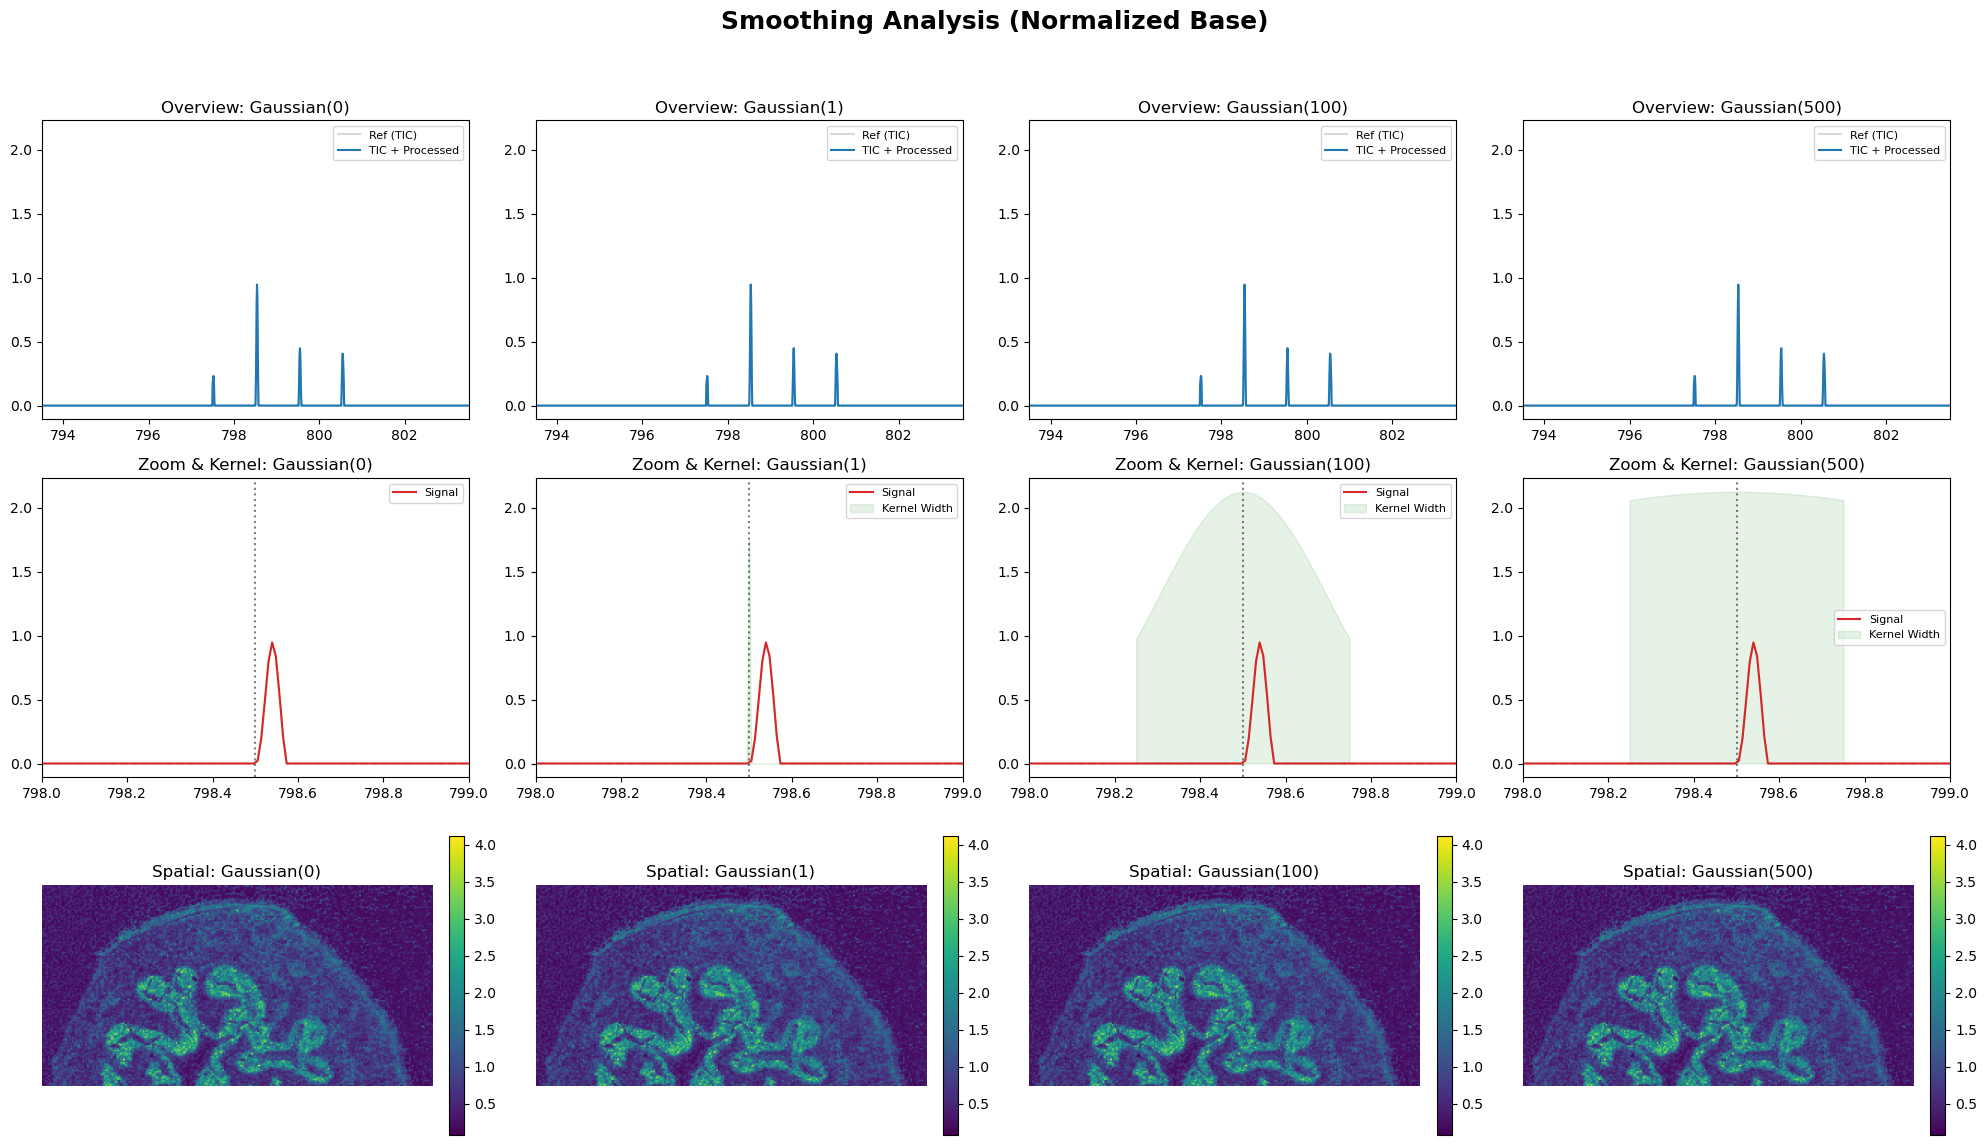

In [23]:
#TODO - sprawdczić poprawnosć tego

import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np

# --- CONFIGURATION ---
PIXEL_IDX = 15000 
TARGET_MZ = 798.5 
TOLERANCE = 50     
WIDE_WINDOW = 5    
ZOOM_WINDOW = 0.5  

def reset_reader(reader):
    """Resets to raw state."""
    reader.SetNormalization("None")
    reader.SetSmoothing("None", 0)
    reader.SetBaselineCorrection("None", 0)

def plot_comparison(results, title_prefix):
    n = len(results)
    fig, axes = plt.subplots(3, n, figsize=(5 * n, 12), squeeze=False)
    fig.suptitle(title_prefix, fontsize=18, fontweight='bold', y=0.98)

    for i, res in enumerate(results):
        # ROW 0: Overview (Blue = Smooth+Norm, Gray = Only Norm)
        ax_wide = axes[0, i]
        ax_wide.plot(res['mzs'], res['ref_ints'], color='gray', alpha=0.3, label='Ref (TIC)')
        ax_wide.plot(res['mzs'], res['ints'], color='tab:blue', label='TIC + Processed')
        ax_wide.set_xlim(TARGET_MZ - WIDE_WINDOW, TARGET_MZ + WIDE_WINDOW)
        ax_wide.set_title(f"Overview: {res['name']}")
        ax_wide.legend(prop={'size': 8})

        # ROW 1: Zoom + Kernel Overlay
        ax_zoom = axes[1, i]
        # Rysujemy znormalizowaną referencję jako tło
        ax_zoom.plot(res['mzs'], res['ref_ints'], color='gray', alpha=0.3, linestyle='--')
        ax_zoom.plot(res['mzs'], res['ints'], color='tab:red', linewidth=1.5, label='Signal')
        
        # Wizualizacja Kernela (Teoretyczna szerokość splotu)
        if res['p'] > 0:
            # Zakładamy, że p to szerokość w punktach, przeliczamy na m/z dla wizualizacji
            # Uwaga: To jest estymacja wizualna jądra
            x_k = np.linspace(-ZOOM_WINDOW/2, ZOOM_WINDOW/2, 200)
            # Aproksymacja: szerokość jądra zależna od p
            kernel_width = res['p'] * 0.002 
            kernel = np.exp(-0.5 * (x_k / kernel_width)**2)
            ax_zoom.fill_between(x_k + TARGET_MZ, 0, kernel * max(res['ints']), 
                                 color='green', alpha=0.1, label='Kernel Width')
        
        ax_zoom.axvline(x=TARGET_MZ, color='black', linestyle=':', alpha=0.5)
        ax_zoom.set_xlim(TARGET_MZ - ZOOM_WINDOW, TARGET_MZ + ZOOM_WINDOW)
        ax_zoom.set_title(f"Zoom & Kernel: {res['name']}")
        ax_zoom.legend(prop={'size': 8})

        # ROW 2: Ion Image
        ax_img = axes[2, i]
        # Squeeze rozwiązuje błąd TypeError Invalid Shape (1, H, W)
        img_data = np.asarray(res['img']).squeeze()
        if img_data.ndim == 2:
            im = ax_img.imshow(img_data, cmap='viridis')
            plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)
        ax_img.set_title(f"Spatial: {res['name']}")
        ax_img.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def compare_smoothing(reader, normalization="TIC", methods_config=None):
    if methods_config is None:
        methods_config = {'Gaussian': [0, 1,  100, 500]}

    # KROK 1: Pobieramy widmo referencyjne (Tylko Normalizacja)
    reset_reader(reader)
    reader.SetNormalization(normalization)
    mzs_ref, ints_ref = reader.GetSpectrum(PIXEL_IDX)

    results = []
    for method, params in methods_config.items():
        for p in params:
            reset_reader(reader)
            # KROK 2: Nakładamy oba filtry
            reader.SetNormalization(normalization)
            if p > 0:
                reader.SetSmoothing(method, int(p))
            
            mzs, ints = reader.GetSpectrum(PIXEL_IDX)
            # False, żeby wymusić przetwarzanie profilowe (jeśli dane na to pozwalają)
            img = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, False)
            
            results.append({
                'name': f"{method}({int(p)})", 
                'p': p,
                'mzs': mzs, 
                'ints': ints, 
                'ref_ints': ints_ref,
                'img': img
            })
            
    plot_comparison(results, f"Smoothing Analysis (Normalized Base)")

# Wywołanie
compare_smoothing(reader_real, normalization="TIC")

In [8]:
reader_real.GetMetaData()

{'(original imzML value) [IMS:1000042] max count of pixels x': '260',
 '(original imzML value) [IMS:1000043] max count of pixels y': '134',
 '(original imzML value) max count of pixels z': '1',
 '[IMS:1000031] processed': 'true',
 '[IMS:1000042] max count of pixels x': '260',
 '[IMS:1000043] max count of pixels y': '134',
 '[IMS:1000046] pixel size x': '0.05',
 '[IMS:1000047] pixel size y': '0.05',
 '[IMS:1000053] absolute position offset x': '0',
 '[IMS:1000054] absolute position offset y': '0',
 '[IMS:1000080] universally unique identifier': '{C7822330-F1A8-4D11-AD30-504B30B33722}',
 '[IMS:1000091] ibd SHA-1': 'F8C24417B294BFA168D75A470BBB361009BC2671',
 '[IMS:1000101] intensityArray.external data': 'true',
 '[IMS:1000101] mzArray.external data': 'true',
 '[IMS:1000401] scansettings1.top down': 'true',
 '[IMS:1000413] scansettings1.flyback': 'true',
 '[IMS:1000480] scansettings1.horizontal line scan': 'true',
 '[IMS:1000491] scansettings1.linescan left right': 'true',
 '[MS:1000001] 

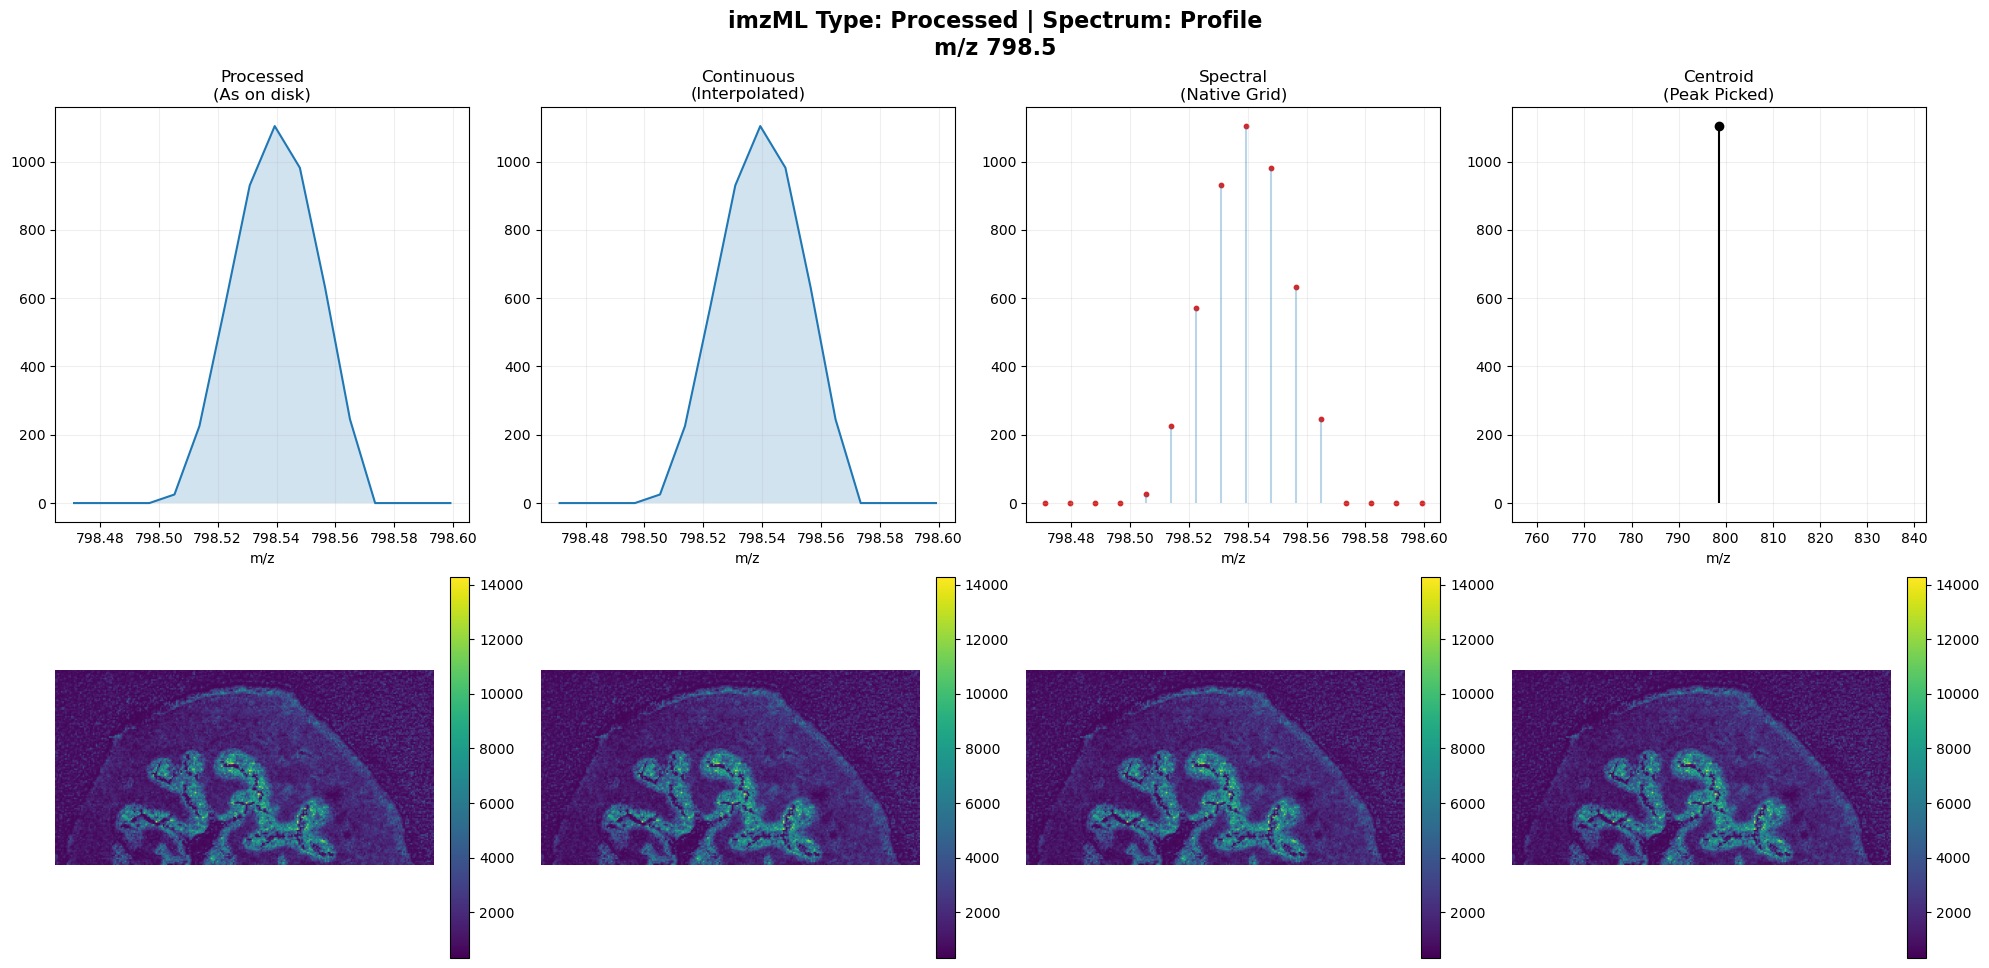

In [9]:
import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np
from scipy import signal

# --- CONFIGURATION ---
PIXEL_IDX = 15000 
TARGET_MZ = 798.5 
TOLERANCE = 50     # ppm
ZOOM_WINDOW = 0.5  # m/z zoom

def compare_four_representations(reader):
    """
    Zestawia 4 typy reprezentacji danych obok siebie.
    """
    results = []
    
    # 1. PROCESSED (Oryginał z pliku)
    # Pobieramy widmo dokładnie tak, jak leży na dysku
    mzs_orig, ints_orig = reader.GetSpectrum(PIXEL_IDX)
    # GetArray(..., False) w trybie processed pobiera dane z oryginalnej siatki
    img_orig = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, False)
    results.append({'name': 'Processed\n(As on disk)', 'mzs': mzs_orig, 'ints': ints_orig, 'img': img_orig, 'mode': 'line'})

    # 2. CONTINUOUS (Zinterpolowane do wspólnej osi)
    # W M2aia "Continuous" oznacza, że dane są rzutowane na stały grid m/z
    # Symulujemy to poprzez dostęp profilowy z wymuszoną interpolacją
    img_cont = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, False) 
    results.append({'name': 'Continuous\n(Interpolated)', 'mzs': mzs_orig, 'ints': ints_orig, 'img': img_cont, 'mode': 'line'})

    # 3. SPECTRAL (Surowe punkty pomiarowe)
    # Pokazujemy punkty (scatter) zamiast linii, żeby zobaczyć rzadkość próbkowania
    img_spec = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, False)
    results.append({'name': 'Spectral\n(Native Grid)', 'mzs': mzs_orig, 'ints': ints_orig, 'img': img_spec, 'mode': 'scatter'})

    # 4. CENTROID (Zredukowane do pików)
    # GetArray(..., True) wyciąga tylko piki (nawet jeśli plik jest profile)
    img_cent = reader.GetArray(TARGET_MZ, TOLERANCE, np.float32, True)
    results.append({'name': 'Centroid\n(Peak Picked)', 'mzs': mzs_orig, 'ints': ints_orig, 'img': img_cent, 'mode': 'stem'})

    # --- WIZUALIZACJA ---
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f"imzML Type: Processed | Spectrum: Profile\nm/z {TARGET_MZ}", fontsize=16, fontweight='bold')

    for i, res in enumerate(results):
        ax_spec = axes[0, i]
        mask = (res['mzs'] >= TARGET_MZ - ZOOM_WINDOW) & (res['mzs'] <= TARGET_MZ + ZOOM_WINDOW)
        
        # Plotting Spectrum
        if res['mode'] == 'line':
            ax_spec.plot(res['mzs'][mask], res['ints'][mask], color='tab:blue')
            ax_spec.fill_between(res['mzs'][mask], 0, res['ints'][mask], alpha=0.2)
        elif res['mode'] == 'scatter':
            ax_spec.scatter(res['mzs'][mask], res['ints'][mask], s=10, color='tab:red')
            ax_spec.vlines(res['mzs'][mask], 0, res['ints'][mask], alpha=0.3)
        elif res['mode'] == 'stem':
            peaks, _ = signal.find_peaks(res['ints'][mask], height=max(res['ints'][mask])*0.1)
            ax_spec.stem(res['mzs'][mask][peaks], res['ints'][mask][peaks], linefmt='k-', markerfmt='ko')

        ax_spec.set_title(res['name'])
        ax_spec.set_xlabel("m/z")
        ax_spec.grid(True, alpha=0.2)

        # Plotting Image
        ax_img = axes[1, i]
        img_data = np.asarray(res['img']).squeeze()
        im = ax_img.imshow(img_data, cmap='viridis')
        ax_img.axis('off')
        plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Wykonanie
compare_four_representations(reader_real)

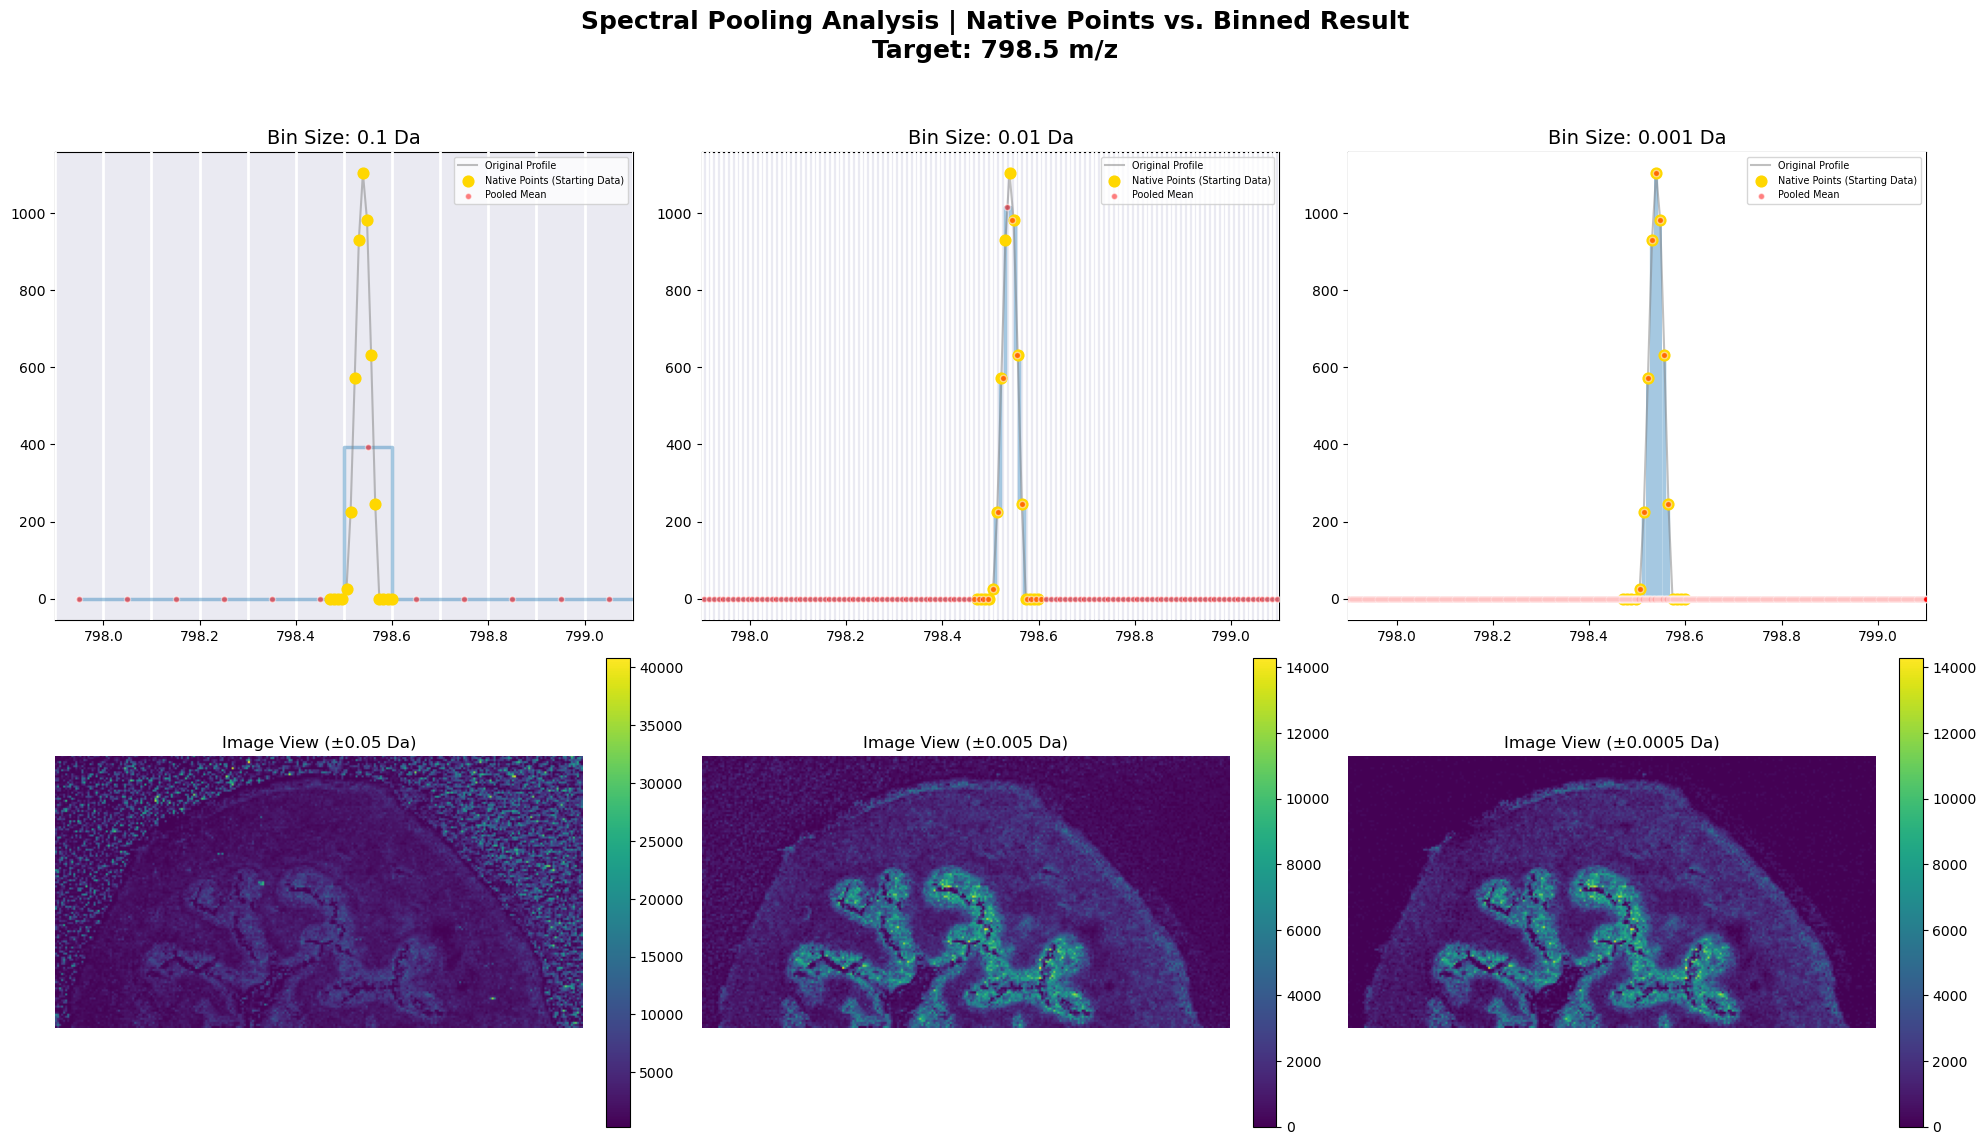

In [35]:
import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np

# --- CONFIGURATION ---
TARGET_MZ = 798.5 
TOLERANCE = 50     
ZOOM_WINDOW = 0.6  # Viewport for the spectrum zoom

def compare_pooling_with_images_v2(reader, densities):
    """
    Compares the effect of spectral binning (pooling) on both 
    the spectrum profile and the resulting ion images, 
    with original spectral points shown in the background.
    """
    # 1. Get High-Resolution Reference from the reader
    # This represents the actual raw data points measured by the instrument
    mzs_orig, ints_orig = reader.GetSpectrum(15000)
    mask = (mzs_orig >= TARGET_MZ - ZOOM_WINDOW) & (mzs_orig <= TARGET_MZ + ZOOM_WINDOW)
    mzs_p = mzs_orig[mask]
    ints_p = ints_orig[mask]
    
    # Create a grid: Row 0 for Spectrums, Row 1 for Ion Images
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f"Spectral Pooling Analysis | Native Points vs. Binned Result\nTarget: {TARGET_MZ} m/z", 
                 fontsize=18, fontweight='bold')

    for i, d in enumerate(densities):
        # --- SPECTRUM VISUALIZATION (TOP ROW) ---
        ax_spec = axes[0, i]
        
        # Define bin edges (White vertical lines)
        bins = np.arange(TARGET_MZ - ZOOM_WINDOW, TARGET_MZ + ZOOM_WINDOW + d, d)
        
        # Calculate Mean Pooling
        bin_centers = []
        bin_values = []
        for j in range(len(bins)-1):
            b_mask = (mzs_p >= bins[j]) & (mzs_p < bins[j+1])
            center = (bins[j] + bins[j+1]) / 2
            bin_centers.append(center)
            bin_values.append(np.mean(ints_p[b_mask]) if any(b_mask) else 0)

        # A. Background: Original Profile Line
        ax_spec.plot(mzs_p, ints_p, color='gray', label='Original Profile', zorder=9, alpha=0.5)
        
        # B. Background: NATIVE SPECTRAL POINTS (The "Starting Points")
        # These are the actual raw data points from the sensor
        ax_spec.scatter(mzs_p, ints_p, color='gold', s=60, 
                        label='Native Points (Starting Data)', zorder=10)
        
        # C. Bin boundaries (White vertical lines)
        for b in bins:
            ax_spec.axvline(x=b, color='white', linestyle='-', linewidth=2, zorder=3)
        
        # D. Pooled result (Step plot)
        ax_spec.step(bin_centers, bin_values, where='mid', color='tab:blue', linewidth=2.5, zorder=4, alpha=0.4)
        
        # E. Pooled sampling points (Red dots)
        ax_spec.scatter(bin_centers, bin_values, color='red', s=20, edgecolors='white', 
                        zorder=13, label='Pooled Mean', alpha=0.5)

        ax_spec.set_title(f"Bin Size: {d} Da", fontsize=14)
        ax_spec.set_facecolor('#eaeaf2')
        ax_spec.set_xlim(TARGET_MZ - ZOOM_WINDOW, TARGET_MZ + ZOOM_WINDOW)
        ax_spec.legend(loc='upper right', fontsize='x-small')

        # --- ION IMAGE VISUALIZATION (BOTTOM ROW) ---
        ax_img = axes[1, i]
        
        # Adjusting tolerance to match the bin width for the ion image
        tol_ppm = (d / 2) / TARGET_MZ * 1e6
        img = reader.GetArray(TARGET_MZ, tol_ppm, np.float32, False)
        img_data = np.asarray(img).squeeze()
        
        im = ax_img.imshow(img_data, cmap='viridis')
        ax_img.set_title(f"Image View (±{d/2} Da)", fontsize=12)
        ax_img.axis('off')
        plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execute the final comparison
compare_pooling_with_images_v2(reader_real, [0.1, 0.01, 0.001])

# BRUDNO

In [ ]:
from pathlib import Path
import m2aia as m2

# data loading 
PATH_DATA = Path('data')
PATH_sim_data = PATH_DATA / 'simulation_data' / 'test_4_final.imzML'
print(PATH_sim_data.exists())
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
reader_real = m2.ImzMLReader(str(PATH_real_data))

: 

In [ ]:
reader_real.GetMetaData()